In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline

### import class wrapper

from classy import Class

### math stuff
import numpy as np

### plotting stuff
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import interp1d
import tqdm as tqdm


In [2]:
### RUN LCDM for comparison first
lcdm = Class()
lcdm.set({ 'h': 0.67,
          'omega_cdm': 0.12,
          # add neutrinos to make it more realistic
          'N_ncdm': 1,
          'deg_ncdm': 3, # 3 neutrino species
          'm_ncdm': 0.02, # in eV, set a small mass for the neutrino to avoid issues with the early universe
          'T_ncdm': 0.71611, # T_ncdm/T_cmb, set to the standard value for neutrinos
          'N_ur': 0, # no massless neutrinos
          })
lcdm.compute()

### Read background quantities for LCDM

bg_lcdm = lcdm.get_background()
z_lcdm = bg_lcdm['z']
rho_cdm_lcdm = bg_lcdm['(.)rho_cdm']
rho_g_lcdm = bg_lcdm['(.)rho_g']
rho_nu_lcdm = bg_lcdm['(.)rho_ncdm[0]']
H_lcdm = bg_lcdm['H [1/Mpc]']
rho_tot_lcdm = bg_lcdm['(.)rho_tot']
z_eq_lcdm = lcdm.get_current_derived_parameters(['z_eq'])
print(f"Redshift of matter-radiation equality in LCDM: {z_eq_lcdm['z_eq']:.2f}")


Redshift of matter-radiation equality in LCDM: 3392.85


In [3]:
Omega_cdm_lcdm_ini = rho_cdm_lcdm[0] / rho_tot_lcdm[-1]*(1+z_lcdm[0])**(-3)
print(f"Omega_cdm at z=0 in LCDM: {Omega_cdm_lcdm_ini:.4f}")

Omega_cdm at z=0 in LCDM: 0.2673


(1e-12, np.float64(1.7361173286365357e+47))

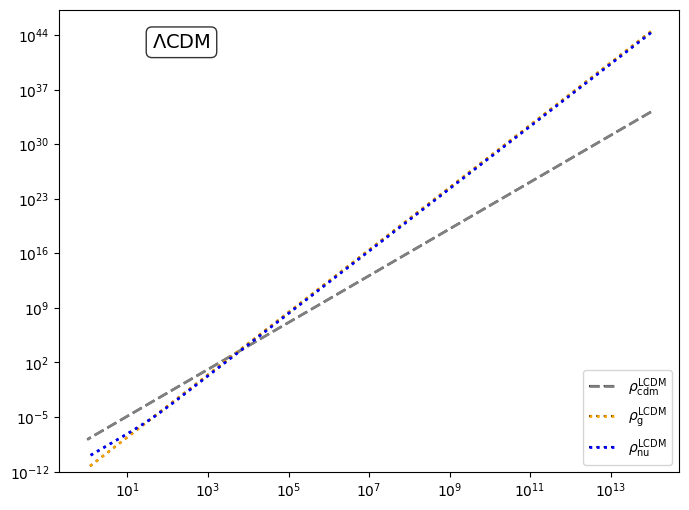

In [4]:
### Plot the background evolution for LCDM
plt.figure(figsize=(8,6))
plt.semilogx(1+z_lcdm, rho_cdm_lcdm, label=r'$\rho_{\mathrm{cdm}}^{\mathrm{LCDM}}$', linewidth=2, ls = '--',
              path_effects=[pe.withStroke(linewidth=1.5, foreground='black')], color='grey')
plt.semilogx(1+z_lcdm, rho_g_lcdm, label=r'$\rho_{\mathrm{g}}^{\mathrm{LCDM}}$', linewidth=2, ls = ':',
              path_effects=[pe.withStroke(linewidth=1.5, foreground='black')], color='orange')
plt.semilogx(1+z_lcdm, rho_nu_lcdm, label=r'$\rho_{\mathrm{nu}}^{\mathrm{LCDM}}$', linewidth=2, ls = ':',
              path_effects=[pe.withStroke(linewidth=1.5, foreground='black')], color='blue')
plt.legend()
plt.text(0.15, 0.95, fr'$\Lambda$CDM', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.yscale('log')
plt.ylim(1e-12, None)

In [5]:
### Run CLASS ###
AccCLASS = {}
tau_acc = 3600*24*365*1e9 # one billion years in s
#f_acc = 0.1 # today's fraction of DM that could have accelerated at some point in the past
m_dcdm = 1e16
m_wdm = m_dcdm
eta = 1

q_bin_num_list = [1000, 2000, 5000, 10000]

for bins in tqdm.tqdm(q_bin_num_list):
    print(f'Running CLASS for eta = {eta} and q-bin number = {bins}') 
    AccCLASS[bins] = Class()
    # AccCLASS[eta].set(common_settings)
    AccCLASS[bins].set({
                    # 'gauge': 'synchronous',
                    'h': 0.67810,
                    'omega_cdm': 0.0, # Set the CDM density to 0 since we are including it as part of the WDM component
                    'omega_ini_dcdm': 0.12, # Set the density of the WDM component to account for the fraction of DM that is accelerating
                    'eta_wdm': eta, 
                    "tau_wdm": tau_acc,
                    "m_wdm_in_GeV": m_wdm, # Set a default value for the WDM mass in GeV
                    "m_cdm_in_GeV": m_dcdm, # Set a default value for the CDM mass in GeV
                    "N_ncdm": 2, # We need at least 2 ncdm species to have the WDM component
                    "deg_ncdm": "3,1", # 3 neutrino species and 1 degrees of freedom for the WDM component 
                    "m_ncdm": "0.02, 1e24", # Set a small mass for the neutrino species and a large mass for the WDM component (in eV)
                    "T_ncdm": "0.71611, 0.1", # Set the same temperature for the WDM component as for the neutrinos
                    "ncdm_N_momentum_bins" : f"15, {bins}", # Set a higher number of momentum bins for the WDM component
                    "N_ur": 0.00441, # Set the number of massless neutrino species to 0 since we are including them as ncdm species
                    "ncdm_quadrature_strategy": "0, 4", 
                    })
    AccCLASS[bins].compute()
        
# Initialize dictionaries for background and perturbation quantities
bgAcc = {}
z, a, H = {}, {}, {}
rho_dcdm = {}
rho_acc = {}
p_acc = {}
rho_tot = {}

# Loop over each beta value and extract necessary background and perturbation data
for bins in q_bin_num_list:
    ### BACKGROUND
    bgAcc[bins] = AccCLASS[bins].get_background()
    
    # Extract some background cosmological quantities
    H[bins] = bgAcc[bins]['H [1/Mpc]']
    z[bins] = bgAcc[bins]['z']

    # Extract energy densities
    rho_dcdm[bins] = bgAcc[bins]['(.)rho_dcdm']
    rho_acc[bins] = bgAcc[bins]['(.)rho_ncdm[1]']
    rho_tot[bins] = bgAcc[bins]['(.)rho_tot']
    p_acc[bins] = bgAcc[bins]['(.)p_ncdm[1]']
        
print(rho_acc[bins])
print(p_acc[bins])

 50%|█████     | 2/4 [00:29<00:31, 15.95s/it]

Running CLASS for eta = 1 and q-bin number = 1000
Running CLASS for eta = 1 and q-bin number = 2000


100%|██████████| 4/4 [04:13<00:00, 86.25s/it]

Running CLASS for eta = 1 and q-bin number = 5000
Running CLASS for eta = 1 and q-bin number = 10000


100%|██████████| 4/4 [04:13<00:00, 63.43s/it]


[1.86721781e+09 1.86184861e+09 1.85649540e+09 ... 1.25059932e-08
 1.24750972e-08 1.24442787e-08]
[3.56816910e+08 3.55561456e+08 3.54310322e+08 ... 2.88717829e-10
 2.87593004e-10 2.86472558e-10]


In [6]:
print(rho_acc[bins]/p_acc[bins])

[ 5.23298578  5.23636232  5.23974405 ... 43.31562509 43.37761028
 43.43968861]


Plotting for bins = 1000
Plotting for bins = 2000
Plotting for bins = 5000
Plotting for bins = 10000


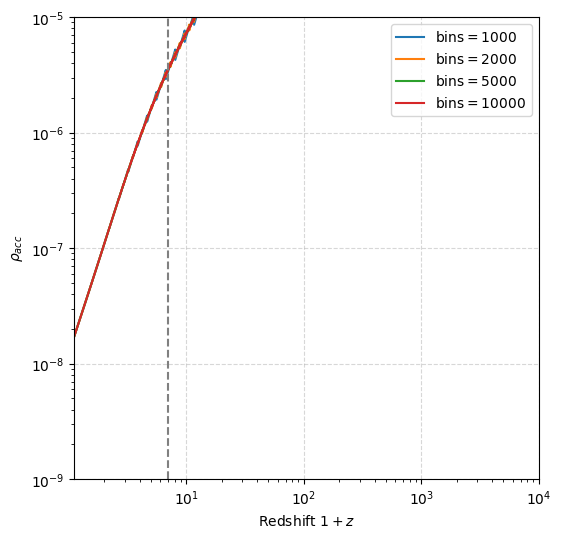

In [7]:
### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
xmax=100

### Cmap viridis
cmap = plt.get_cmap('viridis')
colors = ['C0', 'C1', 'C2', 'C3', 'C4']
rho_cdm_lcdm_interp = interp1d(z_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

for bins in q_bin_num_list:
    print(f'Plotting for bins = {bins}')
    z_mon = z[bins]
    
    ax.plot(1+z_mon, rho_acc[bins], label=rf'$\mathrm{{bins}} = {bins}$', ls = '-')
    ax.set_ylabel(r'$\rho_{acc}$')
    ax.set_xlabel(r'Redshift $1+z$')

ax.legend()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-9, 1e-5)
ax.set_xlim(1.1, 1e4)
ax.grid(ls = '--', alpha = 0.5)
ax.axvline(1+6, color='grey', linestyle='--', label=r'$z_{\mathrm{acc}}$')


Plotting for bins = 1000
Plotting for bins = 2000
Plotting for bins = 5000
Plotting for bins = 10000


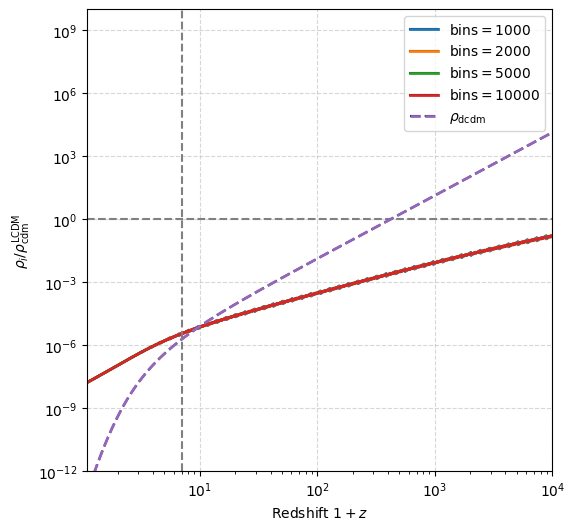

In [8]:
### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
xmax=100

### Cmap viridis
cmap = plt.get_cmap('viridis')
#colors = [cmap(i) for i in np.linspace(0, 1, len(eta_list))]
colors = ['C0', 'C1', 'C2', 'C3', 'C4']
# Interpolate LCDM results to the same redshift values as the monopole runs for easier comparison
rho_cdm_lcdm_interp = interp1d(z_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')


color_index = 0

for bins in q_bin_num_list:
    print(f'Plotting for bins = {bins}')
    z_mon = z[bins]
        
    color_index += 1
    ax.semilogx(1+z_mon, rho_acc[bins], label=rf'$\mathrm{{bins}} = {bins}$', linewidth=2, ls = '-',
                  path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])
    
    ax.set_ylabel(r'$\rho_{i}/\rho_{\mathrm{cdm}}^{\mathrm{LCDM}}$')
    ax.set_xlabel(r'Redshift $1+z$')

ax.axhline(1, color='grey', linestyle='--')

ax.semilogx(1+z_mon, rho_dcdm[bins], label=r'$\rho_{\mathrm{dcdm}}$', linewidth=2, ls = '--',
                  path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])
# ax.semilogx(1+z_mon, rho_g[bins], label=r'$\rho_{\mathrm{g}}$', linewidth=2, ls = ':',
#                   path_effects=[pe.withStroke(linewidth=1.5, foreground='black')], color='orange')

ax.legend()

ax.set_yscale('log')
ax.set_ylim(1e-12, 1e10)
ax.set_xlim(1.1, 1e4)
ax.grid(ls = '--', alpha = 0.5)
ax.axvline(1+6, color='grey', linestyle='--', label=r'$z_{\mathrm{eq}}$')


Plotting for bins = 1000
Plotting for bins = 2000
Plotting for bins = 5000
Plotting for bins = 10000


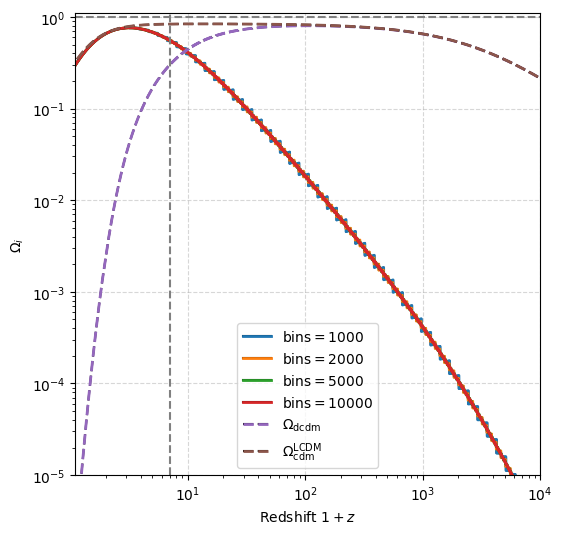

In [9]:
### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
xmax=100

### Cmap viridis
cmap = plt.get_cmap('viridis')
#colors = [cmap(i) for i in np.linspace(0, 1, len(eta_list))]
colors = ['C0', 'C1', 'C2', 'C3', 'C4']
# Interpolate LCDM results to the same redshift values as the monopole runs for easier comparison
rho_cdm_lcdm_interp = interp1d(z_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')


color_index = 0

for bins in q_bin_num_list:
    print(f'Plotting for bins = {bins}')
    z_mon = z[bins]
    
    ax.semilogx(1+z_mon, rho_acc[bins]/rho_tot[bins], label=rf'$\mathrm{{bins}} = {bins}$', linewidth=2, ls = '-',
                  path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])
    
    ax.set_ylabel(r'$\Omega_i$')
    ax.set_xlabel(r'Redshift $1+z$')

ax.axhline(1, color='grey', linestyle='--')

ax.semilogx(1+z_mon, rho_dcdm[bins]/rho_tot[bins], label=r'$\Omega_{\mathrm{dcdm}}$', linewidth=2, ls = '--',
                  path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])
ax.semilogx(1+z_lcdm, rho_cdm_lcdm/rho_tot_lcdm, label=r'$\Omega_{\mathrm{cdm}}^{\mathrm{LCDM}}$', linewidth=2, ls = '--',
              path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])

ax.legend()
ax.set_yscale('log')
ax.set_ylim(1e-5, 1.1)
ax.set_xlim(1.1, 1e4)
ax.grid(ls = '--', alpha = 0.5)
ax.axvline(1+6, color='grey', linestyle='--', label=r'$z_{\mathrm{eq}}$')

Plotting for bins = 1000
Plotting for bins = 2000
Plotting for bins = 5000
Plotting for bins = 10000


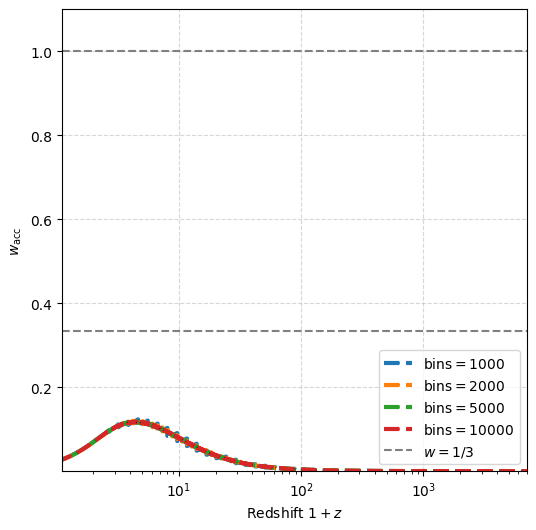

In [12]:
### Plot evolution of rho_adm for different values of f_mon
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
xmax=100

### Cmap viridis
cmap = plt.get_cmap('viridis')
#colors = [cmap(i) for i in np.linspace(0, 1, len(eta_list))]
colors = ['C0', 'C1', 'C2', 'C3', 'C4']
# Interpolate LCDM results to the same redshift values as the monopole runs for easier comparison

for bins in q_bin_num_list:
    print(f'Plotting for bins = {bins}')
    z_mon = z[bins]
    
    # rho_acc = rho_cdm[bins] + rho_adm[bins]
    
    # print(rho_adm[bins])
    ax.semilogx(1+z_mon, p_acc[bins]/(rho_dcdm[bins]+rho_acc[bins]), label=rf'$\mathrm{{bins}} = {bins}$', linewidth=3, ls = '--',
                  path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])

    ax.set_ylabel(r'$w_\mathrm{acc}$')
    ax.set_xlabel(r'Redshift $1+z$')

ax.axhline(1, color='grey', linestyle='--')
ax.axhline(1/3, color='grey', linestyle='--', label=r'$w=1/3$', zorder=-1)

ax.legend()
ax.set_yscale('linear')
ax.set_ylim(1e-4, 1.1)
ax.set_xlim(1.1, 7e3)
ax.grid(ls = '--', alpha = 0.5)


NameError: name 'eta_list' is not defined

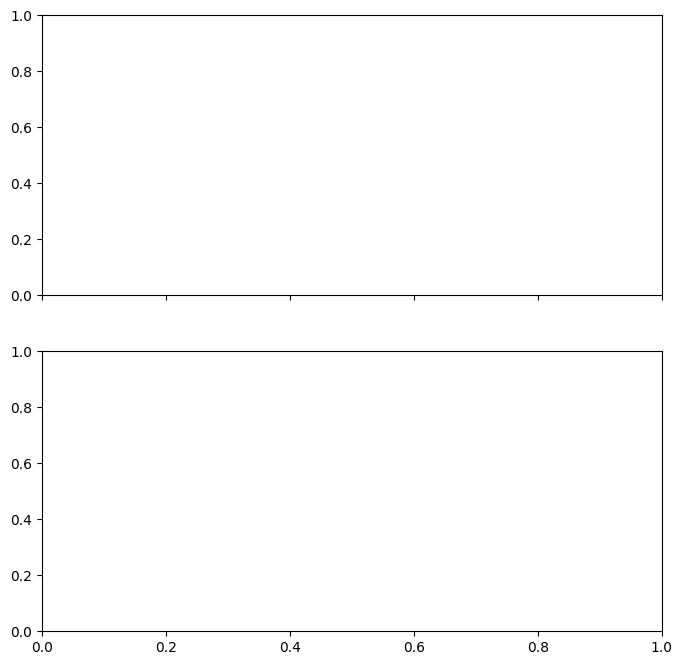

In [11]:
# Set up figure
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Interpolation functions
interp_H_lcdm = interp1d(z_lcdm, H_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')
interp_rho_cdm_lcdm = interp1d(z_lcdm, rho_cdm_lcdm, kind='linear', bounds_error=False, fill_value='extrapolate')

colors = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10"]

# Loop over f_mon values
for i, eta in enumerate(eta_list):
    z_mon = z[eta]
    H_mon = H[eta]
    rho_cdm_mon = rho_dcdm[eta]
    rho_adm_mon = rho_acc[eta]

    # Interpolated LCDM quantities onto z[f_mon] grid
    H_lcdm_interp = interp_H_lcdm(z_mon)
    rho_cdm_lcdm_interp = interp_rho_cdm_lcdm(z_mon)

    color = colors[i]
    
    # Plot 1: H[z_tr] / H_lcdm
    H_line = axs[0].semilogx(1 + z_mon, H_mon / H_lcdm_interp, 
                             linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], 
                             label=rf'$\eta={eta}$', color=color
                    )

    print('Ratio at z=0: ', H_mon[-1]/H_lcdm_interp[-1])
    axs[0].axvline(x=1+z_eq[eta]['z_eq'], linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # z_eq
    
    # Plot 2: rho_cdm[f_mon] / rho_cdm_lcdm
    rho_line = axs[1].semilogx(1 + z_mon, rho_cdm_mon / (rho_cdm_lcdm_interp), linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')], color=color)
    #axs[1].set_ylim(-0.025, 0.12)
    axs[1].axvline(x=1+z_eq[eta]['z_eq'], linestyle='--', linewidth=1.2, alpha=0.7, color=color)  # z_eq

    
# Common plot settings
titles = [
    r'$H(\eta)/H_{\Lambda\mathrm{CDM}}$',
    r'$\rho_{\mathrm{cdm}}(\eta)/\rho_{\mathrm{cdm},\Lambda\mathrm{CDM}}$',
    r'$\chi(\eta)/\chi_{\Lambda\mathrm{CDM}}$'
]

for i, ax in enumerate(axs):
    ax.set_ylabel(titles[i], fontsize=16)
    ax.grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, alpha=0.7)  # reference line at 1 (for ratios)
    #ax.axvline(x=1+20, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)  # z_t_mon line
    # ax.axvline(x=1+3400, color='blue', linestyle='--', linewidth=1.2, alpha=0.7)  # z_eq line
    ax.set_xlim(1, 2e5)
    if i == 0:
        ax.legend(fontsize=16, loc='upper right', frameon=False)
        # ax.text(1+21, 1.025, r'$z_{t,\mathrm{mon}}=20$', fontsize=14, verticalalignment='bottom', horizontalalignment='left', color='gray', rotation=90)
        # ax.text(1+3410, 1.03, r'$z_{\mathrm{eq}}$', fontsize=14, verticalalignment='bottom', horizontalalignment='right', color='blue', rotation=90)
    ax.legend(fontsize=14, loc='upper right', frameon=False)

# X-axis label only on bottom plot
axs[-1].set_xlabel(r'$1+z$', fontsize=18)

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)

plt.show()

# Save the figure
fig.savefig('monopole_background.pdf', dpi=300, bbox_inches='tight')